In [1]:
import numpy as np
from matplotlib import pyplot as plt

In [2]:
#delimiter = the symbol ',' is what seperates each pixel
#skip_header=1 ignore the first row (first row is the titles because were not using pandas)
data = np.genfromtxt('set/digit-recognizer/train.csv', delimiter=',', skip_header=1)

In [3]:
# making sure the data is loaded right
data.shape
m,n=data.shape

In [4]:
# data shuffle
np.random.shuffle(data)
data_dev=data[0:1000].T
Y_dev=data_dev[0] 
X_dev= data_dev[1:n] / 255

data_train=data[1000:m].T
Y_train=data_train[0] 
X_train=data_train[1:n] / 255

In [5]:
def init_params():
    W1=np.random.rand(10,784)-0.5
    b1=np.random.rand(10,1)-0.5
    W2=np.random.rand(10,10)-0.5
    b2=np.random.rand(10,1)-0.5
    return W1, b1, W2, b2

def ReLu(Z):
    return np.maximum(0,Z)

def softmax(Z):
    exp_Z = np.exp(Z - np.max(Z, axis=0)) 
    return exp_Z / np.sum(exp_Z, axis=0)

def forward_prop(W1, b1, W2, b2, X):
    Z1= W1.dot(X)+b1
    A1= ReLu(Z1)
    Z2= W2.dot(A1)+b2
    A2= softmax(Z2)
    return Z1, A1, Z2, A2

def one_hot(Y):
    Y = Y.astype(int)
    one_hot_Y= np.zeros((Y.size, Y.max()+1))
    one_hot_Y[np.arange(Y.size), Y] = 1
    one_hot_Y = one_hot_Y.T
    return one_hot_Y

def derive_RelU(Z):
    return Z>0

def back_prop(Z1, A1, Z2, A2, W2, X, Y):
    m = Y.size
    one_hot_Y=one_hot(Y)
    dZ2= A2 - one_hot_Y
    dW2 = 1/m * dZ2.dot(A1.T)
    db2 = 1 / m * np.sum(dZ2, axis=1, keepdims=True)    
    dZ1 = W2.T.dot(dZ2) * derive_RelU(Z1)
    dW1 = 1 / m * dZ1.dot(X.T)
    db1 = 1 / m * np.sum(dZ1, axis=1, keepdims=True)
    return dW1, db1, dW2, db2

def update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha):
    W1 = W1 - alpha * dW1
    b1 = b1 - alpha * db1
    W2 = W2 - alpha * dW2
    b2 = b2 - alpha * db2
    return W1, b1, W2, b2

In [6]:
def get_predictions(A2):
    return np.argmax(A2, 0)

def get_accuracy(predictions, Y):
    print(predictions, Y)
    return np.sum(predictions == Y) / Y.size

def gradient_descent(X, Y, iterations, alpha):
    W1, b1, W2, b2 = init_params()
    for i in range (iterations): 
        Z1, A1, Z2, A2 = forward_prop(W1, b1, W2, b2, X)
        dW1, db1, dW2, db2 = back_prop(Z1, A1, Z2, A2, W2, X, Y)
        W1, b1, W2, b2 = update_params(W1, b1, W2, b2, dW1, db1, dW2, db2, alpha)
        if i%50 == 0:
            print("Iteraiton: ", i)
            print("Accuracy: ", get_accuracy(get_predictions(A2), Y))
    return W1, b1, W2, b2

In [7]:
W1, b1 , W2, b2 = gradient_descent(X_train, Y_train, 500, 0.1 )

Iteraiton:  0
[1 3 1 ... 5 2 1] [9. 7. 3. ... 7. 8. 8.]
Accuracy:  0.06353658536585366
Iteraiton:  50
[3 7 4 ... 3 8 7] [9. 7. 3. ... 7. 8. 8.]
Accuracy:  0.41597560975609754
Iteraiton:  100
[9 7 4 ... 7 8 7] [9. 7. 3. ... 7. 8. 8.]
Accuracy:  0.5865853658536585
Iteraiton:  150
[9 7 4 ... 7 8 9] [9. 7. 3. ... 7. 8. 8.]
Accuracy:  0.6849024390243903
Iteraiton:  200
[9 7 4 ... 7 8 9] [9. 7. 3. ... 7. 8. 8.]
Accuracy:  0.7431707317073171
Iteraiton:  250
[9 7 7 ... 7 8 8] [9. 7. 3. ... 7. 8. 8.]
Accuracy:  0.7809268292682927
Iteraiton:  300
[9 7 7 ... 7 8 8] [9. 7. 3. ... 7. 8. 8.]
Accuracy:  0.8048536585365854
Iteraiton:  350
[9 7 7 ... 7 8 8] [9. 7. 3. ... 7. 8. 8.]
Accuracy:  0.8201951219512195
Iteraiton:  400
[9 7 7 ... 7 8 8] [9. 7. 3. ... 7. 8. 8.]
Accuracy:  0.8310731707317073
Iteraiton:  450
[9 7 7 ... 7 8 8] [9. 7. 3. ... 7. 8. 8.]
Accuracy:  0.8394634146341463


Prediction: 9
Actual Label: 9


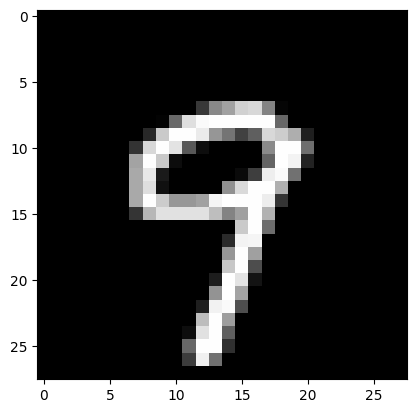

Prediction: 7
Actual Label: 7


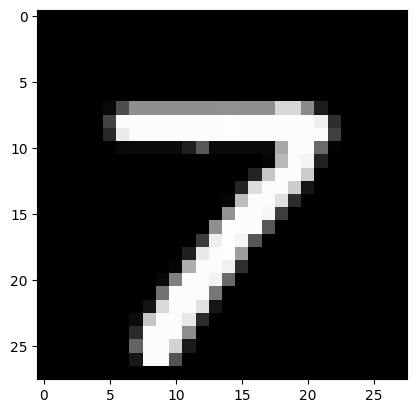

Prediction: 7
Actual Label: 3


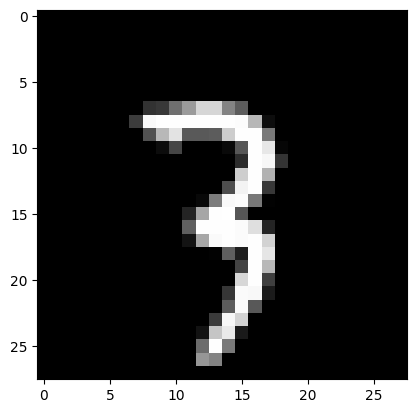

Prediction: 0
Actual Label: 0


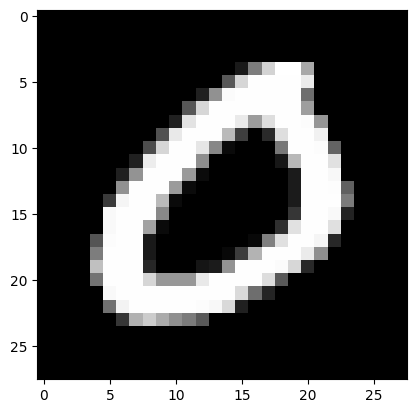

In [8]:
def make_predictions(X, W1, b1, W2, b2):
    # run forward prop
    _, _, _, A2 = forward_prop(W1, b1, W2, b2, X)
    predictions = get_predictions(A2)
    return predictions

def test_prediction(index, W1, b1, W2, b2):
    # get one image as a column
    current_image = X_train[:, index, None]
    prediction = make_predictions(current_image, W1, b1, W2, b2)
    label = Y_train[index]
    
    print(f"Prediction: {prediction[0]}")
    print(f"Actual Label: {int(label)}")
    
    # show image
    current_image = current_image.reshape((28, 28)) * 255
    plt.gray()
    plt.imshow(current_image, interpolation='nearest')
    plt.show()

# test first 4 images
test_prediction(0, W1, b1, W2, b2)
test_prediction(1, W1, b1, W2, b2)
test_prediction(2, W1, b1, W2, b2)
test_prediction(3, W1, b1, W2, b2)